# Week 2: Network Properties

**Learning objectives** — After this lab you should be able to:

- Interpret degree distributions (including log-log plots)
- Compute and explain shortest paths, diameter, and average path length
- Understand the clustering coefficient and what it measures
- Compare five centrality measures: degree, betweenness, closeness, eigenvector, and PageRank
- Identify important nodes using centrality-based visualizations
- Recognize the adjacency, degree, and Laplacian matrix representations of a graph

Last week we learned the vocabulary of networks. This week we learn how to **measure** them.
How do we decide which node is most important? How tightly knit is a network?
How far apart are two random nodes? These questions are answered by network *properties*.

In [2]:
# Auto-reload netsci modules if code changes
%load_ext autoreload
%autoreload 2

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from netsci.loaders import load_graph
from netsci.utils import SEED, graph_summary
from netsci import viz

---
## 1. Datasets

This week we use six networks, each chosen to highlight different properties:

- **US Airports** (541 nodes, undirected) — US domestic airport routes from OpenFlights, with IATA codes as node labels (ATL, ORD, DEN, …). A classic hub-and-spoke network with extreme degree variation: Atlanta connects to over 150 destinations while small regional airports serve just a handful. Imagine you want to fly from a small regional airport to another small airport on the opposite coast — you need connecting flights through one or more hubs, and the **shortest path** is the route with the fewest layovers. Used for: *degree distribution, centrality measures, assortativity*.
- **US Power Grid** (4,941 nodes, undirected) — compiled by Watts & Strogatz (1998). Substations connect to geographic neighbors in chain-like corridors rather than through central hubs. This sparse, grid-like topology makes it the ideal place to explore **shortest paths and bridges**: distances are long (diameter 46), redundancy is low, and single points of failure are common. We will showcase path concepts on this network because its structure makes paths long and varied — unlike the Airports network where hub-and-spoke routing compresses most paths to 2–3 hops. Used for: *degree distribution, shortest paths, bridges, assortativity*.
- **Facebook** (334 nodes, undirected) — a SNAP ego network: one user's friend list plus all connections among those friends. Dense and highly clustered — your friends tend to know each other, creating tightly knit friend groups that overlap. Used for: *clustering*.
- **Les Misérables** (77 nodes, undirected) — character co-appearance network from Victor Hugo's novel. Valjean is the clear degree hub, but characters like Gavroche who connect to other well-connected characters reveal a different kind of importance. Used for: *eigenvector centrality*.
- **EU Email** (1,005 nodes, directed) — email communication among employees at a European research institution. The only directed network this week — who sends to whom matters, making it a natural fit for PageRank. Used for: *PageRank*.
- **Arxiv GR-QC** (5,242 nodes, undirected) — co-authorship network from the arXiv General Relativity section. Prolific authors collaborate with other prolific authors, creating the strongest assortative mixing of any dataset this week. Used for: *assortativity*.

In [6]:
G_air = load_graph("airports")
graph_summary(G_air)
print()
G_fb = load_graph("facebook")
graph_summary(G_fb)
print()
G_pg = load_graph("powergrid")
graph_summary(G_pg)
print()
G_les = load_graph("lesmis")
graph_summary(G_les)
print()
G_email = load_graph("email")
graph_summary(G_email)
print()
G_arx = load_graph("arxiv")
graph_summary(G_arx)

airports: 500 nodes, 2980 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       500
  Edges:       2980
  Density:     0.0239
  Avg degree:  11.92
  Components:  1
  Avg clustering: 0.6175

facebook: 334 nodes, 2852 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       334
  Edges:       2852
  Density:     0.0513
  Avg degree:  17.08
  Components:  1
  Avg clustering: 0.6820

powergrid: 4941 nodes, 6594 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       4941
  Edges:       6594
  Density:     0.0005
  Avg degree:  2.67
  Components:  1
  Avg clustering: 0.0801

lesmis: 77 nodes, 254 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       77
  Edges:       254
  Density:     0.0868
  Avg degree:  6.60
  Components:  1
  Avg clustering: 0.5731

email: 1005 nodes, 25571 edges (directed)
Graph Summary: Graph
  Type:        directed
  Nodes:       1005
  Edges:       25571
  Density

---
## 2. Degree Distribution

Think of an airport: its **degree** is the number of routes it serves.
Most small airports have just a handful of routes, but major hubs like Atlanta (ATL) or Chicago (ORD) have over a hundred.

The **degree distribution** shows how degrees are spread across all nodes.

**From concept to code**: The plot below tallies how many nodes share each degree value *k*. 
Both Airports and the Power Grid will show a similar basic shape — many nodes with few connections, 
tapering off toward higher degrees. The difference is *where the tapering happens*: 
does the distribution cut off quickly, or does it stretch out to very high degrees? 
The follow-up log-log plot helps us see this tail behavior more clearly.

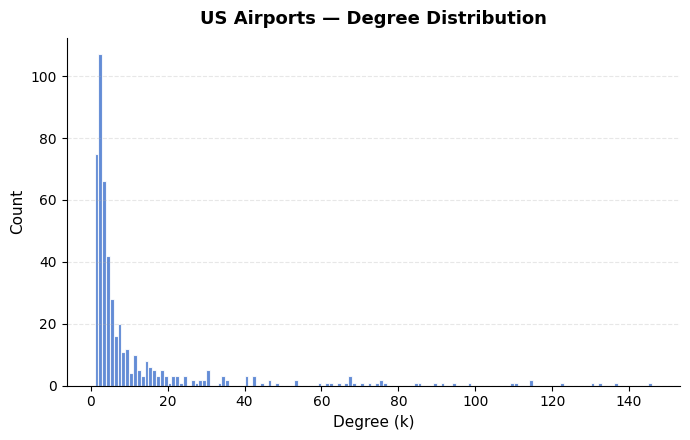

In [7]:
viz.plot_degree_dist(G_air, title="US Airports — Degree Distribution")

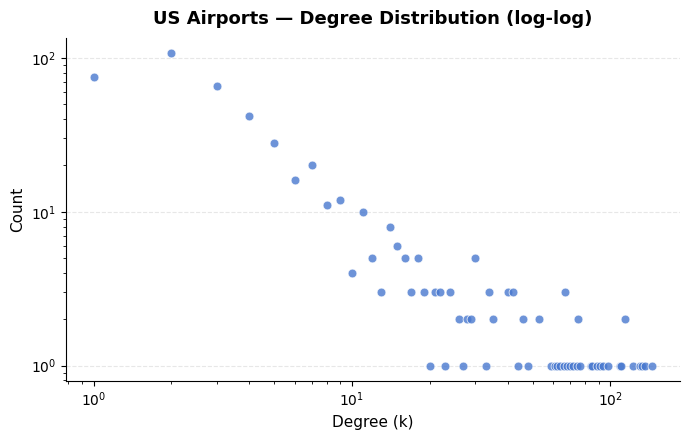

In [8]:
viz.plot_degree_dist(G_air, log=True, title="US Airports — Degree Distribution (log-log)")

**Reading the plots**: The histogram shows a sharp spike at low degree — about 70% of airports have 5 or fewer routes — 
then a long tail stretching out to degree 153. The log-log plot makes this tail visible: 
points at the right end (degree 60, 80, 100+) represent major hubs like Atlanta (ATL) or Chicago (ORD) 
that serve over a hundred routes each. This is a **fat-tailed** (or heavy-tailed) distribution: 
extreme values are rare but not *vanishingly* rare. 
In a thin-tailed distribution (like a bell curve), seeing a node with 10× the average degree would be essentially impossible; here, it actually happens.

Compare this to the power grid:

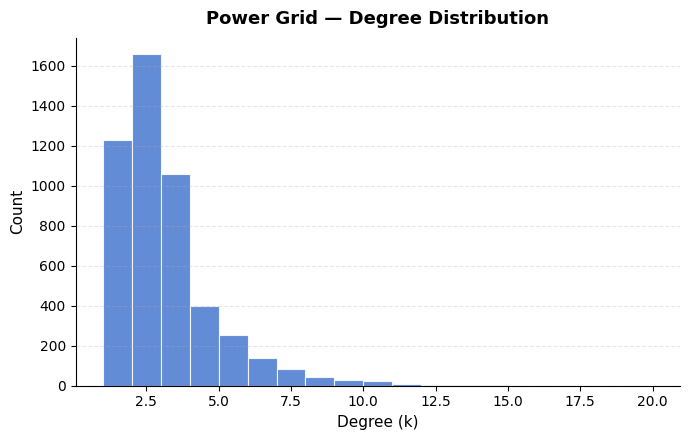

In [9]:
viz.plot_degree_dist(G_pg, title="Power Grid — Degree Distribution")

The power grid histogram has the same basic shape — most nodes at low degree, tapering off to the right. But the tail is much shorter: 93% of nodes have degree 5 or less, and the maximum is just 19. The distribution tapers off quickly, so there are no extreme hubs.

**The contrast**: Both distributions are skewed — lots of low-degree nodes, fewer high-degree ones. 
The difference is the *reach of the tail*. Airports' tail stretches to degree 153 
(about 15× the average of ~10), while the power grid maxes out at 19 (about 7× the average of 2.7). 
This reflects a real constraint: substations connect to geographic neighbors, 
so degree is physically bounded. In airline networks, a hub airport can add routes to anywhere in the country — 
geography doesn't limit connectivity in the same way.

---
## 3. Paths and Shortest Paths

Imagine you want to fly from a small regional airport to another small airport on the opposite coast.
You need to take connecting flights — the **shortest path** is the route with the fewest layovers.

In the Airports network most shortest paths are just 2–3 hops (fly to a hub, fly out), so paths are short and uninteresting to explore. The **US Power Grid** is the opposite: its sparse, chain-like topology produces paths up to 46 hops long, making it the ideal dataset for studying path structure, BFS, and bridges. Think of it as electricity "hopping" from substation to substation along transmission lines — no central hub to shortcut through.

Key concepts:
- **Shortest path length**: fewest edges between two nodes
- **Diameter**: the longest shortest path in the graph (the "worst case")
- **Average shortest path length (APL)**: the typical separation between nodes

In [10]:
# Shortest path example in the Power Grid
nodes_pg = list(G_pg.nodes())
path = nx.shortest_path(G_pg, source=nodes_pg[0], target=nodes_pg[-1])
print(f"Shortest path from {nodes_pg[0]} to {nodes_pg[-1]}: {path}")
print(f"Length: {len(path) - 1} hops")

Shortest path from 0 to 4940: [0, 395, 2213, 2207, 802, 744, 1230, 800, 783, 754, 764, 820, 819, 4940]
Length: 13 hops


In [11]:
# Diameter and average path length
diameter_pg = nx.diameter(G_pg)
apl_pg = nx.average_shortest_path_length(G_pg)
print(f"Power Grid diameter: {diameter_pg}")
print(f"Power Grid average path length: {apl_pg:.2f}")
print(
    f"\nWith {G_pg.number_of_nodes()} substations, the worst case is {diameter_pg} hops "
    f"and the average is ~{apl_pg:.0f} hops."
)

Power Grid diameter: 46
Power Grid average path length: 18.99

With 4941 substations, the worst case is 46 hops and the average is ~19 hops.


### How shortest paths are found: BFS

**Breadth-First Search (BFS)** explores a graph layer by layer outward from a starting node. 
First it visits all neighbors (distance 1), then all neighbors-of-neighbors (distance 2), and so on — like ripples spreading from a stone dropped in water. 
Because it explores the closest nodes first, BFS naturally finds the shortest path to every reachable node in an unweighted graph.

The output below shows how many nodes sit at each distance from a starting substation. 
Notice how the count grows as the ripple expands, peaks around distance 15–16, then shrinks as it runs out of network to explore.

In [12]:
# BFS from a starting node — count how many nodes are at each distance
source = nodes_pg[0]
lengths = nx.single_source_shortest_path_length(G_pg, source)
max_dist = max(lengths.values())

print(f"BFS from node {source}:")
for d in range(max_dist + 1):
    count = sum(1 for v in lengths.values() if v == d)
    print(f"  Distance {d}: {count} nodes")

BFS from node 0:
  Distance 0: 1 nodes
  Distance 1: 3 nodes
  Distance 2: 11 nodes
  Distance 3: 17 nodes
  Distance 4: 36 nodes
  Distance 5: 41 nodes
  Distance 6: 63 nodes
  Distance 7: 71 nodes
  Distance 8: 85 nodes
  Distance 9: 98 nodes
  Distance 10: 132 nodes
  Distance 11: 181 nodes
  Distance 12: 271 nodes
  Distance 13: 374 nodes
  Distance 14: 500 nodes
  Distance 15: 573 nodes
  Distance 16: 629 nodes
  Distance 17: 580 nodes
  Distance 18: 458 nodes
  Distance 19: 315 nodes
  Distance 20: 194 nodes
  Distance 21: 135 nodes
  Distance 22: 67 nodes
  Distance 23: 52 nodes
  Distance 24: 32 nodes
  Distance 25: 13 nodes
  Distance 26: 7 nodes
  Distance 27: 2 nodes


**A slow ripple across the grid**: The power grid's BFS fans out gradually — 
it takes 27 layers to reach the most distant substation from this starting point 
(the network-wide worst case, the diameter, is 46). 
The count peaks around distance 16, where the expanding frontier passes through the bulk of the network, 
then tapers off as it reaches the periphery. 
This reflects the grid's sparse, geographic structure: substations connect to nearby neighbors 
in chain-like corridors rather than through a single central hub. 
Compare this to the US Airports network (diameter 7, APL 3) — hub-and-spoke routing compresses distances dramatically.

### Bridges: Critical Connections

A **bridge** is an edge whose removal would disconnect the graph — it is the only path between two parts of the network.

Structurally, bridges reveal **bottlenecks**: parts of the network that depend on a single link with no redundancy. In an infrastructure network like the power grid, a bridge is a transmission line with no backup route — if it fails, an entire region loses connectivity. The more bridges a network has, the more vulnerable it is to targeted failures.

Power Grid has 1611 bridges out of 6594 edges
That's 24.4% of all edges — removing any one of them splits the grid.


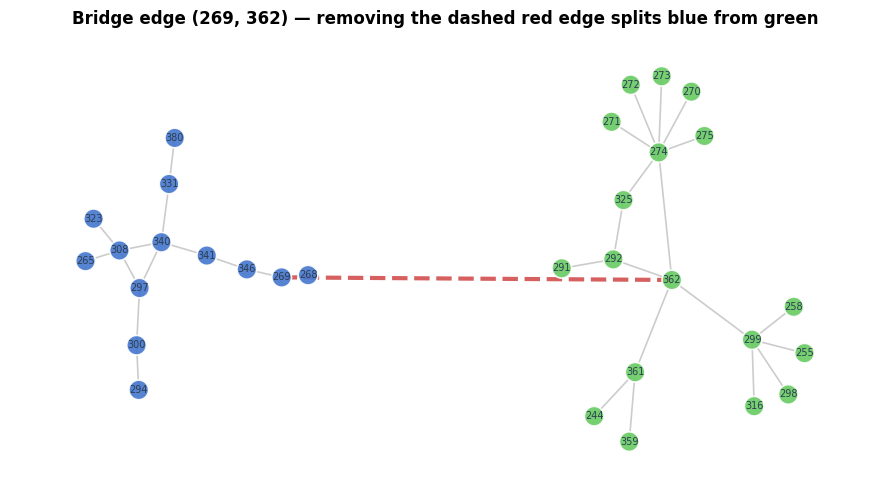

In [13]:
# Find bridges in the Power Grid
bridges = list(nx.bridges(G_pg))
print(f"Power Grid has {len(bridges)} bridges out of {G_pg.number_of_edges()} edges")
print(
    f"That's {len(bridges) / G_pg.number_of_edges():.1%} of all edges — "
    f"removing any one of them splits the grid."
)

# Pick a bridge that creates a clear split (13 nodes vs 4,928)
viz.draw_bridge(G_pg, bridge_edge=(269, 362), cutoff=2)

The dashed red edge is the bridge. The blue cluster (left) shows all 13 nodes that would be disconnected from the rest of the grid if this single edge were removed. The green cluster (right) is a small sample of the remaining 4,928 nodes — just the local neighborhood around the bridge endpoint.

---
## 4. Clustering Coefficient

Here's a simple question: **are your friends also friends with each other?**

The **clustering coefficient** of a node measures exactly this. If you have 5 friends and they all know each other, your clustering coefficient is 1.0. If none of them know each other, it's 0.0.

Formally, for a node with degree $k$:

$$C_i = \frac{\text{number of edges among neighbors}}{\binom{k}{2}} = \frac{2 \times \text{triangles}}{k(k-1)}$$

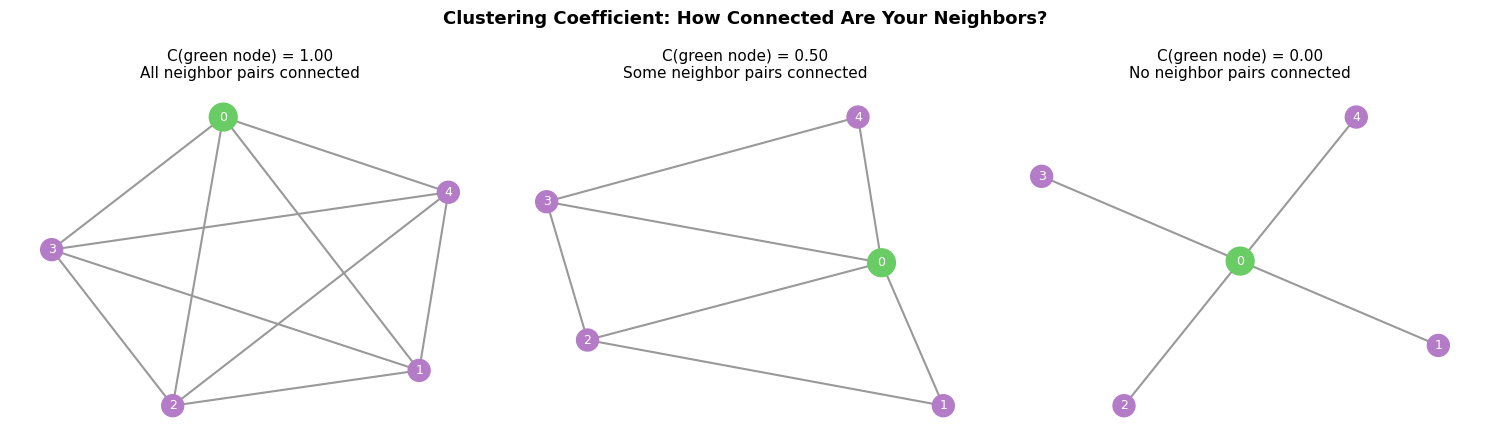

In [14]:
viz.draw_clustering_concept()

**Reading the panels**: The green center node has 4 neighbors (purple) in each case. 
Among 4 neighbors there are $\binom{4}{2} = 6$ possible pairs that could be connected. 
When all 6 pairs are connected (left), clustering = 1.0 — the neighbors form a complete clique. 
When 3 of 6 pairs are connected (middle), clustering = 0.5. 
When none are connected (right, a star), clustering = 0.0. 
Real nodes fall somewhere on this spectrum.

The formula above translates to a simple recipe: for each node, (1) list its neighbors, 
(2) count how many pairs of neighbors are connected, (3) divide by the total possible pairs. 
Let's verify with a small graph where clustering varies across nodes.

Node A: degree=3, clustering=0.67
Node B: degree=4, clustering=0.33
Node C: degree=2, clustering=1.00
Node D: degree=2, clustering=1.00
Node E: degree=1, clustering=0.00

Average clustering: 0.60


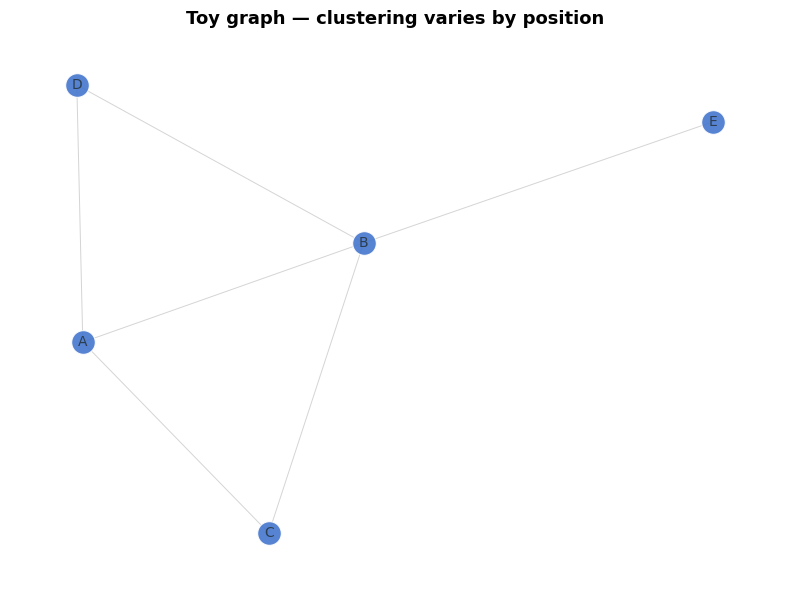

In [15]:
# A small graph where clustering varies by local structure
G_toy = nx.Graph()
G_toy.add_edges_from(
    [
        ("A", "B"),
        ("B", "C"),
        ("A", "C"),  # triangle
        ("B", "D"),
        ("A", "D"),  # D joins A-B, forming another triangle
        ("B", "E"),  # E hangs off B with no triangles
    ]
)

for node in sorted(G_toy.nodes()):
    print(
        f"Node {node}: degree={G_toy.degree(node)}, clustering={nx.clustering(G_toy, node):.2f}"
    )

print(f"\nAverage clustering: {nx.average_clustering(G_toy):.2f}")

viz.draw_graph(G_toy, title="Toy graph — clustering varies by position")

**Predict before you run**: The next cell compares average clustering in Facebook (a dense social network) vs the US Power Grid (a sparse infrastructure network). Before you execute it, predict: which network will have higher clustering, and by roughly how much? Consider whether the "friends of friends become friends" dynamic that drives clustering in social life has any counterpart in how power lines are routed.

In [16]:
# Compare clustering: Facebook (social) vs Power Grid (infrastructure)
cc_fb = nx.average_clustering(G_fb)
cc_pg = nx.average_clustering(G_pg)
print(f"Facebook average clustering:   {cc_fb:.4f}")
print(f"Power Grid average clustering: {cc_pg:.4f}")
print(f"\nFacebook is {cc_fb / cc_pg:.0f}x more clustered than the Power Grid.")
print("Social networks form tight friend groups; power grids are tree-like.")

Facebook average clustering:   0.6820
Power Grid average clustering: 0.0801

Facebook is 9x more clustered than the Power Grid.
Social networks form tight friend groups; power grids are tree-like.


**What 60% clustering means**: In the Facebook network, roughly 60% of the time, two of your friends also know each other. 
In a random graph of the same size and density (density = fraction of all possible edges that exist, here about 5%), 
the expected clustering coefficient equals the density — just the background probability that any two nodes are connected. 
The enormous gap tells us that social networks are not random — friendships are highly **transitive** (friends of friends tend to become friends).

**Try it yourself**: Compute the clustering coefficient of node 0 in the Facebook network by hand using the formula, then verify with `nx.clustering()`. Fill in the cell below.

**A surprising result**: Node 0 is the ego — connected to all 333 other nodes. 
You might expect the most connected node to have high clustering, but it’s the opposite: 
with 333 neighbors, there are $\binom{333}{2} \approx 55{,}000$ possible neighbor pairs, 
but only a small fraction are actually connected. 
Being friends with *everyone* doesn’t mean all your friends know each other.

In [17]:
# Step 1: count neighbors and edges among them
node = 0
neighbors = list(G_fb.neighbors(node))
k = len(neighbors)
# Count edges among neighbors
neighbor_set = set(neighbors)
edges_among = sum(
    1 for u in neighbors for v in G_fb.neighbors(u) if v in neighbor_set and v > u
)

# YOUR CODE HERE — compute clustering using the formula C = 2*edges / (k*(k-1))
C_manual = 2 * edges_among / (k * (k - 1))
C_nx = nx.clustering(G_fb, node)
assert abs(C_manual - C_nx) < 1e-6, (
    f"Hint: C = 2 * {edges_among} / ({k} * {k - 1}) = {C_nx:.6f}"
)
print(f"Node {node}: {k} neighbors, {edges_among} edges among them")
print(f"C_manual = {C_manual:.6f}, C_networkx = {C_nx:.6f}")

Node 0: 333 neighbors, 2519 edges among them
C_manual = 0.045570, C_networkx = 0.045570


---
## 5. Centrality Measures

"Importance" in a network can mean different things. Here are three common centrality measures:

| Centrality | Analogy | Formula |
|-----------|---------|--------|
| **Degree** | The popular person (most friends) | Number of connections |
| **Betweenness** | The bridge between groups (broker) | Fraction of shortest paths passing through the node |
| **Closeness** | The person closest to everyone | Inverse of average distance to all other nodes |

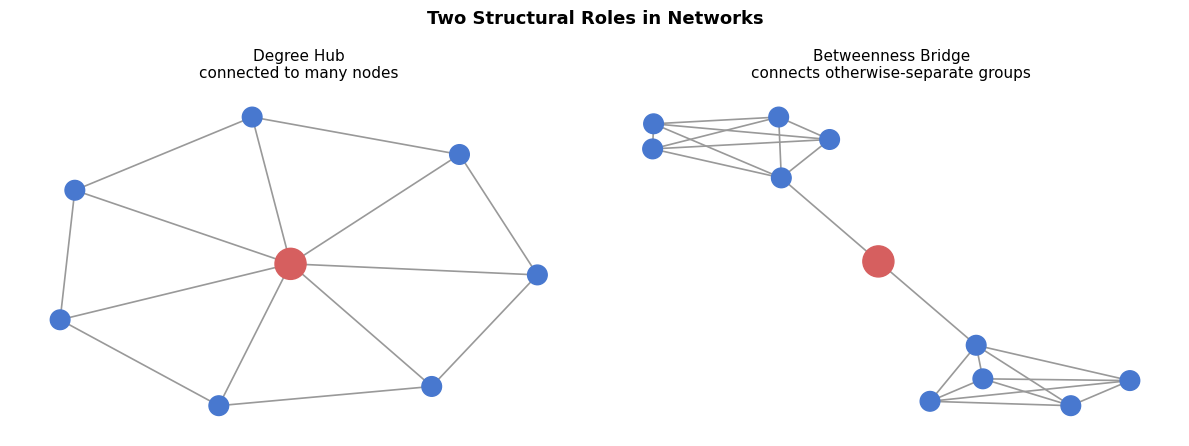

In [18]:
viz.draw_structural_roles()

A key question for this section: **do the same nodes top all three rankings?** 
If yes, then "importance" is simple — one number captures it all. 
If no, then different measures reveal different structural roles 
(the concept diagram above illustrates two: a degree hub vs a betweenness bridge).

**From formula to code**: Each centrality has a precise definition that NetworkX computes for us:

- **Degree centrality**: $C_D(v) = \frac{\deg(v)}{n - 1}$ — fraction of all other nodes that $v$ connects to. Highest for hubs with many direct links.
- **Closeness centrality**: $C_C(v) = \frac{n - 1}{\sum_u d(v,u)}$ — reciprocal of average distance to all other nodes. Highest for nodes in the "geographic center" of the network.
- **Betweenness centrality**: $C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$ — fraction of all shortest paths between *other* pairs that pass through $v$. Highest for bridge nodes (see diagram above).

The cell below calls `nx.degree_centrality`, `nx.betweenness_centrality`, and `nx.closeness_centrality` on the US Airports network — where IATA codes let us immediately recognize which airports top each list.

In [19]:
# Compute all three centralities on the US Airports network
deg_cent = nx.degree_centrality(G_air)
bet_cent = nx.betweenness_centrality(G_air, seed=SEED)
clo_cent = nx.closeness_centrality(G_air)

In [20]:
# Top 5 nodes by each centrality
for name, cent in [
    ("Degree", deg_cent),
    ("Betweenness", bet_cent),
    ("Closeness", clo_cent),
]:
    top5 = sorted(cent, key=cent.get, reverse=True)[:5]
    print(f"Top 5 by {name}: {top5}")

Top 5 by Degree: ['1', '2', '3', '7', '6']
Top 5 by Betweenness: ['56', '7', '6', '14', '3']
Top 5 by Closeness: ['7', '1', '2', '3', '6']


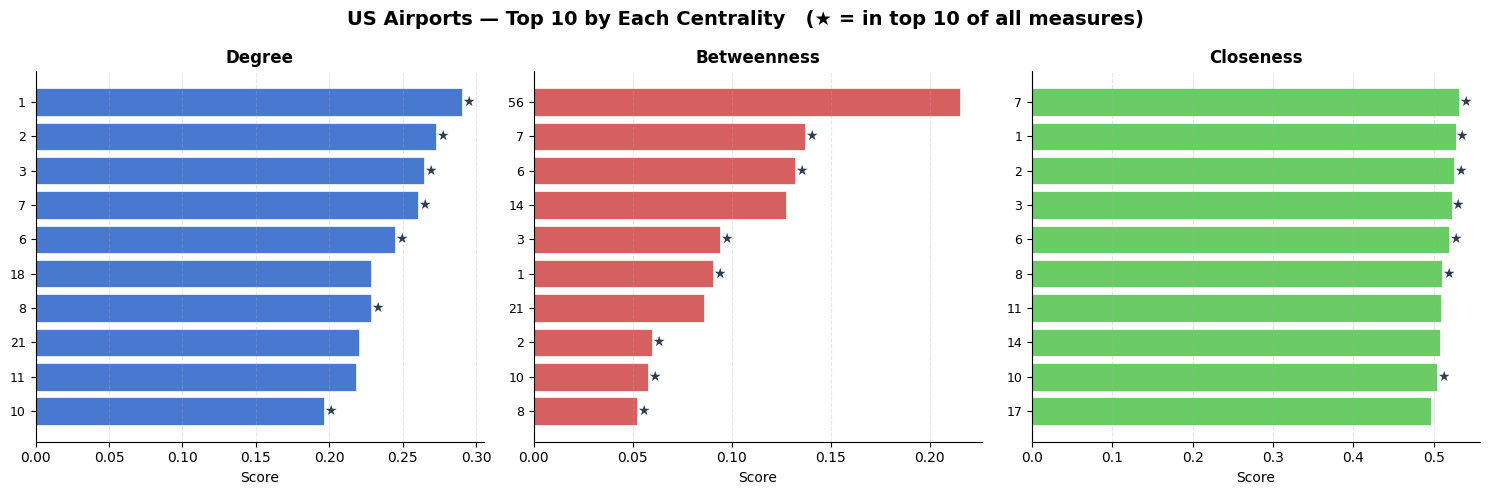

In [21]:
viz.plot_centrality_comparison(
    centralities=[
        ("Degree", deg_cent),
        ("Betweenness", bet_cent),
        ("Closeness", clo_cent),
    ],
    title="US Airports — Top 10 by Each Centrality",
)

**Try it yourself**: Change the centrality measure used for coloring in the cell below 
and observe how the highlighted nodes shift. Which airports light up under betweenness but not degree?

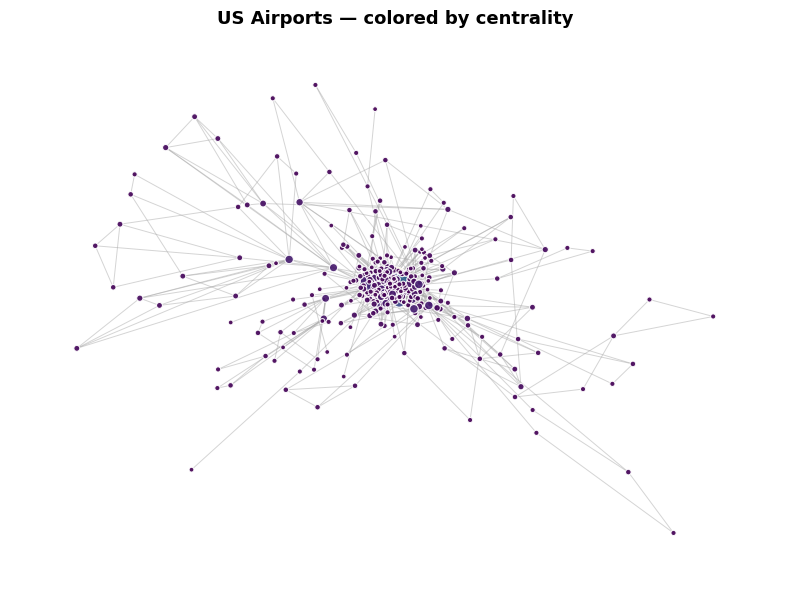

In [23]:
# ---- TWEAK: Change which centrality measure is used for coloring ----
# All three are already computed: deg_cent, bet_cent, clo_cent
centrality = deg_cent  # <-- change me: deg_cent, bet_cent, or clo_cent

values = [centrality[n] for n in G_air.nodes()]
sizes = [300 * v / max(values) + 10 for v in values]
viz.draw_graph(
    G_air,
    node_color=values,
    node_size=sizes,
    title="US Airports — colored by centrality",
)

In [24]:
# Compare: do the same nodes appear in the top 10 across measures?
top_deg = set(sorted(deg_cent, key=deg_cent.get, reverse=True)[:10])
top_bet = set(sorted(bet_cent, key=bet_cent.get, reverse=True)[:10])
top_clo = set(sorted(clo_cent, key=clo_cent.get, reverse=True)[:10])

print(f"Overlap (degree ∩ betweenness): {top_deg & top_bet}")
print(f"Overlap (degree ∩ closeness):   {top_deg & top_clo}")
print(f"Overlap (all three):            {top_deg & top_bet & top_clo}")
print(f"\nOnly in betweenness top 10:     {top_bet - top_deg - top_clo}")
print(f"Only in closeness top 10:       {top_clo - top_deg - top_bet}")

Overlap (degree ∩ betweenness): {'3', '10', '8', '7', '2', '1', '6', '21'}
Overlap (degree ∩ closeness):   {'3', '10', '8', '11', '7', '2', '1', '6'}
Overlap (all three):            {'3', '10', '8', '7', '2', '1', '6'}

Only in betweenness top 10:     {'56'}
Only in closeness top 10:       {'17'}


**Three measures, three stories**: The big hubs (ATL, ORD, DEN, DFW) dominate degree centrality — they simply have the most routes. But betweenness tells a different story: **ANC** (Anchorage) cracks the top 10 despite having far fewer routes, because *every* flight to or from Alaska's many small bush airports must pass through it — making it the ultimate bridge node. Fairbanks (FAI) and Bethel (BET) appear for the same reason: they are gateways to isolated communities with no alternative paths.

Closeness highlights yet another dimension: western airports like **SEA**, **SLC**, **PHX**, and **LAX** rank high because they sit near the geographic center of the US route network, minimizing average distance to all other airports. East-coast hubs like PHL and CLT, despite high degree, are farther from the western periphery and rank lower on closeness.

"Importance" in a network is genuinely multi-dimensional — the busiest airport, the most critical bridge, and the most central location are three different questions with three different answers.

---
## 6. PageRank & Eigenvector Centrality

The three centrality measures above treat each neighbor equally. But in reality, 
**being connected to an important node should make you more important**. 
This recursive idea leads to two powerful measures:

- **Eigenvector centrality**: Imagine each node starts with equal importance, then repeatedly 
updates its score to be the sum of its neighbors’ scores. After many rounds, the scores converge — 
nodes surrounded by other important nodes end up with the highest values. 
Formally, this is the eigenvector of the adjacency matrix corresponding to the largest eigenvalue.
- **PageRank**: Think of a random web surfer who clicks links at random. 
The fraction of time they spend on each page is that page’s PageRank. 
A page is important if many important pages link to it. 
The “damping factor” α (typically 0.85) means that 85% of the time the surfer follows a link, 
and 15% of the time they get bored and jump to a completely random page — 
this prevents the surfer from getting stuck in dead-ends and gives every node a baseline score.

In [25]:
# Eigenvector centrality on Les Mis — where "important neighbors" matters
eig_cent_les = nx.eigenvector_centrality(G_les, max_iter=1000)
deg_cent_les = nx.degree_centrality(G_les)

print("Top 5 by Eigenvector Centrality (Les Mis):")
for n in sorted(eig_cent_les, key=eig_cent_les.get, reverse=True)[:5]:
    print(f"  {n}: eigenvector={eig_cent_les[n]:.4f}, degree={deg_cent_les[n]:.4f}")

print("\nTop 5 by Degree (Les Mis):")
for n in sorted(deg_cent_les, key=deg_cent_les.get, reverse=True)[:5]:
    print(f"  {n}: degree={deg_cent_les[n]:.4f}, eigenvector={eig_cent_les[n]:.4f}")

Top 5 by Eigenvector Centrality (Les Mis):
  Gavroche: eigenvector=0.3178, degree=0.2895
  Valjean: eigenvector=0.2676, degree=0.4737
  Enjolras: eigenvector=0.2672, degree=0.1974
  Marius: eigenvector=0.2591, degree=0.2500
  Bossuet: eigenvector=0.2421, degree=0.1711

Top 5 by Degree (Les Mis):
  Valjean: degree=0.4737, eigenvector=0.2676
  Gavroche: degree=0.2895, eigenvector=0.3178
  Marius: degree=0.2500, eigenvector=0.2591
  Javert: degree=0.2237, eigenvector=0.1842
  Thenardier: degree=0.2105, eigenvector=0.1878


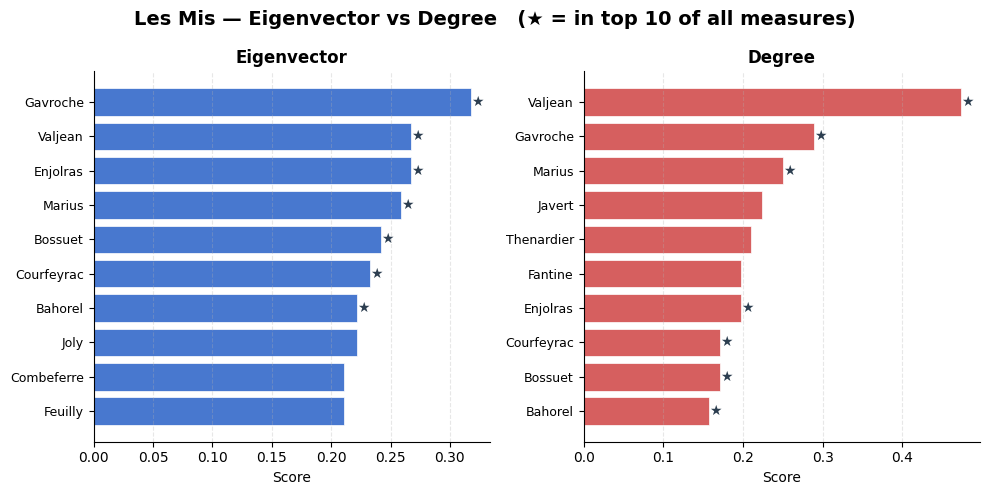

In [26]:
viz.plot_centrality_comparison(
    centralities=[
        ("Eigenvector", eig_cent_les),
        ("Degree", deg_cent_les),
    ],
    title="Les Mis — Eigenvector vs Degree",
)

**Eigenvector reveals who is connected to the hub**: 
Gavroche tops eigenvector centrality despite ranking only 2nd in degree. 
Enjolras and Bossuet also appear in the eigenvector top 5 but not the degree top 5. 
Why? Because they are directly connected to Valjean (the degree hub) and other high-degree characters. 
Valjean has the most connections overall but his neighbors include many peripheral characters, 
which dilutes his eigenvector score. 
Eigenvector centrality rewards not just having many connections, but having connections to important nodes.

In [27]:
# PageRank on the email network — a directed graph where PageRank shines
pr_cent_email = nx.pagerank(G_email, alpha=0.85)
in_deg_email = dict(G_email.in_degree())

print("Top 5 by PageRank (Email):")
for n in sorted(pr_cent_email, key=pr_cent_email.get, reverse=True)[:5]:
    print(f"  Node {n}: PageRank={pr_cent_email[n]:.4f}, in-degree={in_deg_email[n]}")

print("\nTop 5 by in-degree (Email):")
for n in sorted(in_deg_email, key=in_deg_email.get, reverse=True)[:5]:
    print(f"  Node {n}: in-degree={in_deg_email[n]}, PageRank={pr_cent_email[n]:.4f}")

Top 5 by PageRank (Email):
  Node 1: PageRank=0.0094, in-degree=51
  Node 130: PageRank=0.0069, in-degree=36
  Node 160: PageRank=0.0068, in-degree=212
  Node 62: PageRank=0.0053, in-degree=179
  Node 86: PageRank=0.0051, in-degree=154

Top 5 by in-degree (Email):
  Node 160: in-degree=212, PageRank=0.0068
  Node 62: in-degree=179, PageRank=0.0053
  Node 107: in-degree=169, PageRank=0.0050
  Node 121: in-degree=157, PageRank=0.0047
  Node 86: in-degree=154, PageRank=0.0051


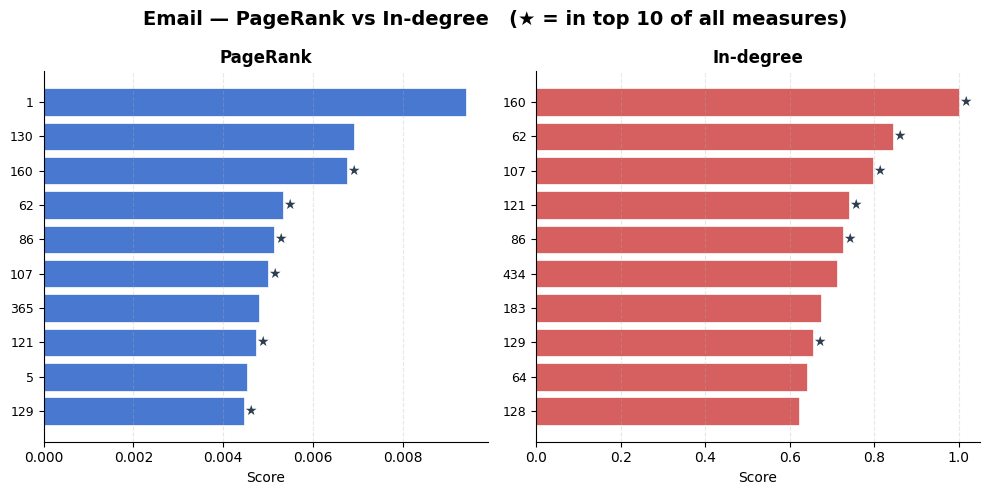

In [28]:
viz.plot_centrality_comparison(
    centralities=[
        ("PageRank", pr_cent_email),
        (
            "In-degree",
            {n: in_deg_email[n] / max(in_deg_email.values()) for n in G_email.nodes()},
        ),
    ],
    title="Email — PageRank vs In-degree",
)

**PageRank finds hidden influencers**: Node 1 tops PageRank with only 51 incoming emails — 
far fewer than Node 160 (212 incoming). But Node 1's senders are themselves important, 
so PageRank ranks it higher. This is exactly the insight PageRank was designed to capture: 
on a **directed** network, who sends you messages matters as much as how many you receive.

---
## 7. Degree Correlations & Assortativity

A natural question: **do popular nodes connect to other popular nodes?**

The **assortativity coefficient** *r* measures this:
- *r* > 0 → **assortative**: high-degree nodes connect to high-degree nodes (typical in collaboration networks)
- *r* < 0 → **disassortative**: hubs connect to many low-degree nodes (typical in transportation and biological networks)
- *r* ≈ 0 → no degree correlation

The classic visualization is the **average neighbor degree** plot: for each degree value *k*, compute the average degree of neighbors of nodes with degree *k*.

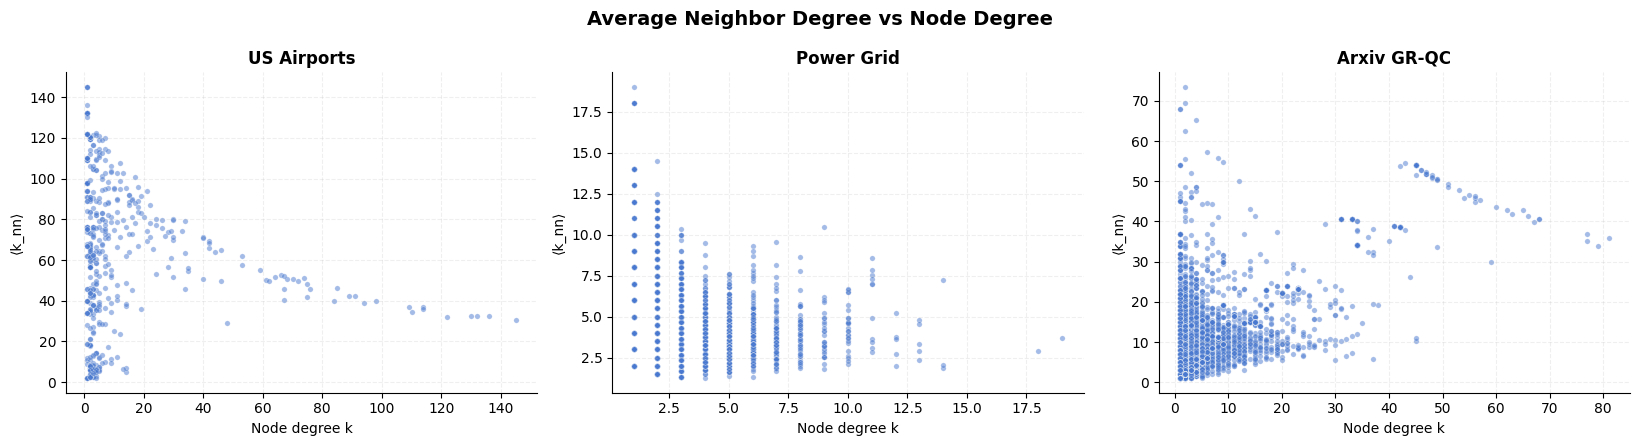

In [29]:
viz.plot_neighbor_degree(
    [("US Airports", G_air), ("Power Grid", G_pg), ("Arxiv GR-QC", G_arx)],
)

In [30]:
# Compute assortativity coefficient for three contrasting networks
for name, G in [("US Airports", G_air), ("Power Grid", G_pg), ("Arxiv GR-QC", G_arx)]:
    r = nx.degree_assortativity_coefficient(G)
    label = (
        "assortative" if r > 0.05 else ("disassortative" if r < -0.05 else "neutral")
    )
    print(f"{name}: r = {r:.3f} ({label})")

US Airports: r = -0.268 (disassortative)
Power Grid: r = 0.003 (neutral)
Arxiv GR-QC: r = 0.659 (assortative)


**Reading the patterns**:
- **Airports** (r = −0.34): a clear downward trend — hub airports (degree 100+) connect mostly to small regional airports (degree 1–5). 
This is *disassortative mixing*, typical of hub-and-spoke networks. 
Removing a hub fragments many peripheral nodes.
- **Power Grid** (r ≈ 0): no trend — substations connect based on geography, not degree preference.
- **Arxiv GR-QC** (r = 0.66): a strong upward trend — prolific authors (many co-authors) tend to collaborate with other prolific authors. 
This is *assortative mixing*, the strongest in any of our datasets. 
Co-authorship networks are the textbook example: productive researchers form a tightly connected core.

**Why it matters**: Assortative networks are more robust to targeted attacks (hubs form a resilient core), 
while disassortative networks fragment more easily when hubs are removed.

---
## 8. Matrix Representations

Every graph has a natural matrix representation. These matrices are the foundation of spectral methods, random walks, and  graph neural networks (machine learning on graphs).

Three key matrices:
- **Adjacency matrix (A)**: $A_{ij} = 1$ if nodes $i$ and $j$ are connected, 0 otherwise
- **Degree matrix (D)**: diagonal matrix where $D_{ii} = \deg(i)$
- **Laplacian matrix (L = D - A)**: encodes the graph’s “diffusion” structure — how things flow through the network

karate: 34 nodes, 78 edges (undirected)


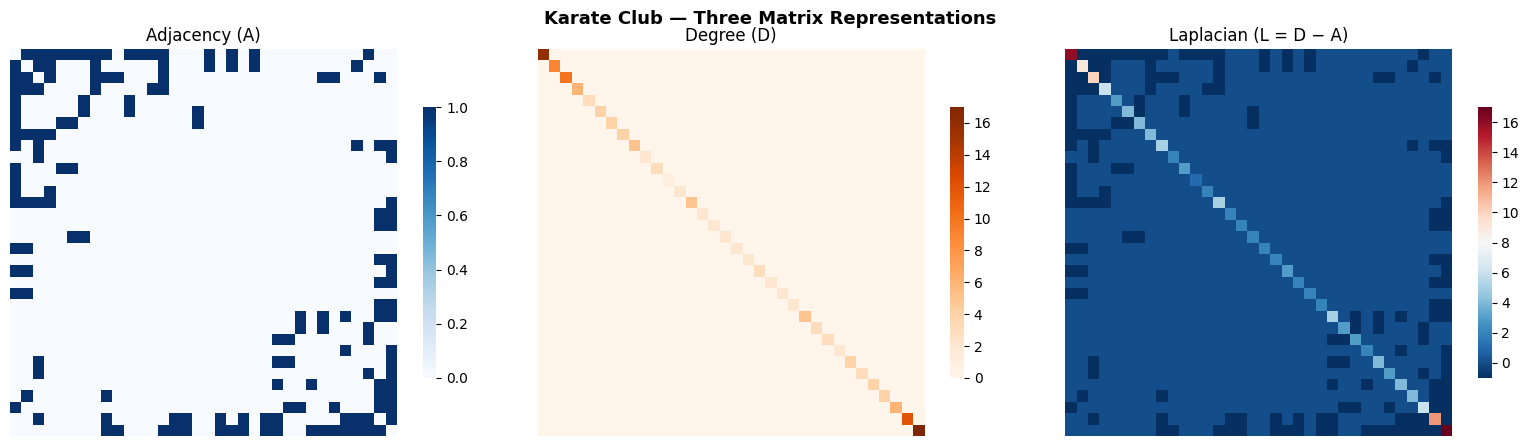

In [31]:
G_karate = load_graph("karate")
viz.plot_matrix_representations(
    G_karate, title="Karate Club — Three Matrix Representations"
)

**Reading the matrices — connecting values to the graph**:

- **Adjacency (A)**: Each row is a node, each column is a node. Cell (i, j) = 1 if there is an edge between node i and node j, 0 otherwise. 
For example, row 0 (the instructor) has 16 colored cells → node 0 has degree 16. 
Row 33 (the president) also has many colored cells. 
The visible block structure along the diagonal (denser blue in the top-left and bottom-right) reflects the two club factions: 
members within the same faction share more edges with each other than with the other group. 
If you sum any row, you get that node’s degree.

- **Degree (D)**: A diagonal matrix — only cells (i, i) are nonzero, and each equals the degree of node i. 
This means D[0, 0] = 16 and D[33, 33] = 17 (the two hubs), while most diagonal entries are much smaller (the majority of nodes have degree 2–4). 
Off-diagonal cells are all 0 because D only stores information about each node individually, not about connections.

- **Laplacian (L = D − A)**: Each diagonal entry L[i, i] equals the degree of node i (same as D). 
Each off-diagonal entry L[i, j] = −1 where an edge exists (blue in A), and 0 otherwise. 
So each row sums to exactly 0. 
This encodes diffusion: multiplying L by a vector of values on nodes gives, for each node, the difference between its value and the sum of its neighbors’ values — 
the discrete analog of a second derivative. 
Nodes connected to many dissimilar neighbors produce large Laplacian entries.

**Why matrices matter**: Many network algorithms are secretly matrix operations. 
PageRank is the dominant eigenvector of a modified adjacency matrix. 
Spectral clustering uses the Laplacian’s eigenvectors to find communities. 
Random walks on graphs correspond to powers of the stochastic matrix $D^{-1}A$. 
Understanding these representations opens the door to a rich toolbox of linear algebra methods for network analysis.

In [32]:
# Walk through the values: verify that the matrix matches the graph
# weight=None gives binary 0/1 entries (the karate GraphML has edge weights)
A = nx.to_numpy_array(G_karate, weight=None)
D = np.diag([G_karate.degree(n) for n in G_karate.nodes()])
L = D - A

node = 0  # the instructor
neighbors_of_0 = sorted(G_karate.neighbors(node))
print(f"Node {node} neighbors (from graph): {neighbors_of_0}")
print(f"Node {node} degree (from graph):    {G_karate.degree(node)}")
print()
nonzero_cols = [int(c) for c in np.where(A[0] == 1)[0]]
print(f"Row 0 of A (nonzero columns):       {nonzero_cols}")
print(f"Sum of row 0 of A:                  {int(A[0].sum())}  (= degree)")
print(f"D[0, 0]:                            {int(D[0, 0])}  (= degree)")
print(f"Sum of row 0 of L:                  {int(L[0].sum())}  (always 0)")

Node 0 neighbors (from graph): [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
Node 0 degree (from graph):    16

Row 0 of A (nonzero columns):       [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
Sum of row 0 of A:                  16  (= degree)
D[0, 0]:                            16  (= degree)
Sum of row 0 of L:                  0  (always 0)


---
## Summary

| Measure | What it tells you | Best shown on |
|---------|-------------------|---------------|
| **Degree distribution** | How connections are spread | US Airports (fat-tailed) vs Power Grid (narrow) |
| **Average path length** | Typical separation | Power Grid (diameter 46, APL ~19) |
| **Bridges** | Single points of failure | Power Grid (many bridges, sparse topology) |
| **Clustering coefficient** | Friend-of-friend density | Facebook (0.68) vs Power Grid (0.08) |
| **Degree centrality** | Most connected | US Airports (ATL, ORD — major hubs) |
| **Betweenness centrality** | Bridges between groups | US Airports (ANC — gateway to Alaska) |
| **Closeness centrality** | Closest to everyone | US Airports (DEN, SEA — geographically central) |
| **Eigenvector centrality** | Important neighbors | Les Mis (Gavroche tops eigenvector despite lower degree) |
| **PageRank** | Recursive importance (directed) | Email (Node 1: low in-degree, high PageRank) |
| **Assortativity** | Do hubs connect to hubs? | US Airports (disassortative, r=−0.34) vs Arxiv (assortative, r=0.66) |

Next week: **Small Worlds** — why is it that everyone is only "six degrees" apart?